**Author:** Tianqi Shen & Ziye Ma & GPT-4o

**Date:** 18 November 2025

# Numerical Experiments of Tensor Over-parametrization (Simulated Version)
## Perturbed Matrix Completion

To simulate the effect of tensor over-parameterization in escaping spurious local minima that arise in the matrix space, we consider the following instance of the Matrix Sensing (MS) problem:  
Let the ground truth matrix be
$$
M^*=zz^\top=
\begin{bmatrix}
1 & 0 & 1 \\
0 & 0 & 0 \\
1 & 0 & 1 
\end{bmatrix},
$$
where the ground truth vector is either $z=[1,0,1]^\top$ or $z=[-1,0,-1]^\top$.  
The linear measurement operator $\mathcal{A}:\mathbb{R}^{3\times 3}\to\mathbb{R}^{9}$ is defined through the sensing matrices:
$$
\begin{aligned}
	&A_1 = \begin{bmatrix}
		1 & 0 & 0 \\
		0 & 0 & 0 \\
		0 & 0 & 0 
	\end{bmatrix},
	\quad
	A_2 = \begin{bmatrix}
		0 & 0.5 & 0 \\
		0.5 & 0 & 0 \\
		0 & 0 & 0 
	\end{bmatrix},
    \quad
	A_3 = \begin{bmatrix}
		0 & 0 & 0.15 \\
		0 & 0 & 0 \\
		0.15 & 0 & 0 
	\end{bmatrix},
	\nonumber \\
	&A_4 = \begin{bmatrix}
		0 & 0.5 & 0 \\
		0.5 & 0 & 0 \\
		0 & 0 & 0 
	\end{bmatrix},
	\quad
	A_5 = \begin{bmatrix}
		0 & 0 & 0 \\
		0 & 1 & 0 \\
		0 & 0 & 0 
	\end{bmatrix},
    \quad
    A_6 = \begin{bmatrix}
		0 & 0 & 0 \\
		0 & 0 & 0.5 \\
		0 & 0.5 & 0 
	\end{bmatrix},
	\nonumber \\
	&A_7 = \begin{bmatrix}
		0 & 0 & 0.15 \\
		0 & 0 & 0 \\
		0.15 & 0 & 0 \\
	\end{bmatrix},
	\quad
	A_8 = \begin{bmatrix}
		0 & 0 & 0 \\
		0 & 0 & 0.5 \\
		0 & 0.5 & 0 
	\end{bmatrix},
    \quad
    A_9 = \begin{bmatrix}
		0 & 0 & 0 \\
		0 & 0 & 0 \\
		0 & 0 & 1 
	\end{bmatrix}.
\end{aligned}
$$
We consider the following objective function:
$$
h(x)=f(xx^\top)=\frac{1}{2}\|\mathcal{A}(xx^\top-zz^\top)\|_2^2,
$$
where $x\in\mathbb{R}^3$ is the optimization variable (we still use $X\in\mathbb{R}^{3\times 1}$ later for consistency). The operator $\mathcal{A}$ satisfies the Restricted Isometry Property (RIP) of order 2 with constant $\approx0.866$.  
According to the theoretical results presented in [this paper](https://arxiv.org/abs/2110.10279), the Burer-Monteiro factorization approach may produce a large number of spurious local minima even in problems that are polynomial-time solvable. In particular, for the above matrix sensing instance, spurious solutions exist in the neighborhood of the ground truth vectors $[1,0,1]^\top$ and $[-1,0,-1]^\top$. Moreover, there exist two prominent spurious attractors $\hat{x}\in\mathbb{R}^3$ such that the objective function vanishes at these points, i.e., $h(\hat{x})=0$. These solutions are given by:
$$
\hat{x}_1 = \begin{bmatrix} -1 & 0 & 1 \end{bmatrix}^\top, \quad
\hat{x}_2 = \begin{bmatrix} 1 & 0 & -1 \end{bmatrix}^\top.
$$

In [1]:
%matplotlib inline
#import matplotlib_inline   # setup output image format, do not use 'svg' if need 'pdf' output
#matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import matplotlib
import argparse
import numpy as np
from typing import List, Tuple
from itertools import chain
from tqdm import tqdm

### Functional Helpers for Matrix Computation
- Apply the linear measurement operator $\mathcal{A}$ (*func:* `apply_A`):
$$\mathcal{A}(M)=
\begin{bmatrix}
\langle A_1, M \rangle, \langle A_2, M \rangle, \cdots, \langle A_m, M \rangle
\end{bmatrix}^\top \in\mathbb{R}^{m}.
$$
- Apply the adjoint operator $\mathcal{A}^*$ (*func:* `adjoint_A`):
$$\mathcal{A}^*(y)=\sum_{i=1}^m y_i \cdot A_i \in\mathbb{R}^{n\times n}.$$
- Compute the smallest eigenvalue $\lambda_n$ and eigenvector $u_n$ of a symmetric matrix $G$ (*func:* `min_eigpair_symmetric`):
$$
G=\sum_{\theta=1}^n \lambda_\theta u_\theta u_\theta^\top,\quad
\lambda_1\geq\lambda_2\geq\cdots\geq\lambda_n.
$$
- Compute the smallest nonzero singular value $\sigma_r$ and associated vectors $v_r$ and $q_r$ of $X$ (*func:* `last_nonzero_singular_triplet`):
$$
X=\sum_{\phi=1}^r \sigma_\phi v_\phi q_\phi^\top,\quad
\sigma_1\geq\sigma_2\geq\cdots\geq\sigma_r>0.
$$

In [2]:
def apply_A(A, M):
    return np.einsum("ijk,jk->i", A, M)

def adjoint_A(A, y):
    weighted_A = y[:, np.newaxis, np.newaxis] * A
    G = np.sum(weighted_A, axis=0)
    return 0.5 * (G + G.T)

def min_eigpair_symmetric(G):
    vals, vecs = np.linalg.eigh(G)
    idx = np.argmin(vals)
    return float(vals[idx]), vecs[:, idx]

def last_nonzero_singular_triplet(X, rtol=1e-10):
    """
    Computes the last non-zero singular value (σ_r) of a matrix X,
    along with its corresponding left and right singular vectors (v_r, q_r).

    Parameters:
        X (np.ndarray): Input matrix of shape (n, r). Can also be a vector (1D or 2D).
        rtol (float): Relative tolerance to determine whether a singular value is zero.

    Returns:
        sigma_r (float): The smallest non-zero singular value (σ_r).
        v_r (np.ndarray): Corresponding left singular vector (shape: (n,)).
        q_r (np.ndarray): Corresponding right singular vector (shape: (r,)).

    Raises:
        ValueError: If the matrix has rank 0 (i.e., all singular values are zero).
    """
    # Ensure X is at least 2D (e.g., convert a vector to column matrix if needed)
    X = np.atleast_2d(X)

    # Perform singular value decomposition: X = V S Q^T
    V, S, Qh = np.linalg.svd(X, full_matrices=False)

    # Determine the numerical rank by counting singular values > tolerance
    tol = rtol * S[0]  # tolerance is relative to the largest singular value
    rank = np.sum(S > tol)

    if rank == 0:
        raise ValueError("The input matrix has rank 0 — no non-zero singular values.")

    # Get the last non-zero singular value and its corresponding singular vectors
    sigma_r = S[rank - 1]         # Last non-zero singular value
    v_r = V[:, rank - 1]          # Corresponding left singular vector
    q_r = Qh[rank - 1, :]         # Corresponding right singular vector (from Q^T)

    return sigma_r, v_r, q_r

### Functional Helpers for Matrix Sensing and Optimization
- Evaluate the objective function $h(X)$ in matrix space (*func:* `matrix_objective`):
$$
h(X)=\frac{1}{2}\|\mathcal{A}(XX^\top - ZZ^\top)\|_2^2
=\frac{1}{2}
\langle \mathcal{A}(XX^\top) - b, \mathcal{A}(XX^\top) - b \rangle,\quad
\text{where}\ b=\mathcal{A}(ZZ^\top)=\mathcal{A}(M^*)\in\mathbb{R}^{m}.
$$
- Compute the gradient $\nabla h(X)$ (*func:* `matrix_gradient`):
$$
\nabla h(X)=2\mathcal{A}^*\mathcal{A}(XX^\top - ZZ^\top) X=
2\sum_{i=1}^m \langle A_i, XX^\top - ZZ^\top \rangle A_i X=
2\sum_{i=1}^m (\langle A_i, XX^\top \rangle - b_i) A_i X = 2GX \in\mathbb{R}^{n\times r},
$$
where the symmetric matrix $G\in\mathbb{R}^{n\times n}$ is defined as:
$$
G = \mathcal{A}^*\mathcal{A}(XX^\top - ZZ^\top) 
= \sum_{i=1}^m \langle A_i, XX^\top - ZZ^\top \rangle A_i
= \sum_{i=1}^m (\langle A_i, XX^\top \rangle - b_i) A_i.
$$
- Run vanilla gradient descent (GD) in matrix space (*func:* `run_gd`):
$$ X^{(t+1)} = X^{(t)} - \text{lr} \cdot \nabla h(X^{(t)}) .$$
- Estimate the RIP constant $\delta_p$ via random sampling (*func:* `estimate_delta_p`):
$$
(1-\delta_p) \|XX^\top\|_F^2 \leq \|\mathcal{A}(XX^\top)\|_2^2 \leq (1+\delta_p) \|XX^\top\|_F^2.
$$

In [3]:
def matrix_objective(A, X, b):
    M = X @ X.T
    y = apply_A(A, M)
    r = y - b
    return 0.5 * float(r @ r)

def matrix_gradient(A, X, b):
    M = X @ X.T
    y = apply_A(A, M)
    G_M = adjoint_A(A, y - b)
    return 2.0 * (G_M @ X)

def run_gd(A, Z, b, X0, lr, steps, grad_tol):
    X = X0.copy()
    traj = [X.copy()]
    losses = [matrix_objective(A, X, b)]
    gradnorms = [float(np.linalg.norm(matrix_gradient(A, X, b), "fro"))]
    dists = [np.linalg.norm(X @ X.T - Z @ Z.T, "fro")]
    
    for _ in range(steps):
        nabla_h = matrix_gradient(A, X, b)
        X = X - lr * nabla_h
        
        gnorm = float(np.linalg.norm(matrix_gradient(A, X, b), "fro"))
        traj.append(X.copy())
        losses.append(matrix_objective(A, X, b))
        gradnorms.append(gnorm)
        dists.append(np.linalg.norm(X @ X.T - Z @ Z.T, "fro"))
        if gnorm <= grad_tol:
            break
        
    return traj, np.array(losses), np.array(gradnorms), np.array(dists)

def estimate_delta_p(A, p, num_samples=5000, seed=0, matrix_type='symmetric', normalize=True):
    """
    Estimate RIP constant delta_p for a linear operator A.

    Parameters:
    -----------
    A : np.ndarray
        Array of shape (m, n, n), representing m sensing matrices A_i of size n x n.
    p : int
        Target rank for low-rank matrix sampling.
    num_samples : int
        Number of random samples to estimate the RIP constant.
    seed : int
        Random seed for reproducibility.
    matrix_type : str
        Type of matrix to sample: 'general', 'symmetric', or 'psd'.
    normalize : bool
        Whether to normalize sampled matrices to unit Frobenius norm.

    Returns:
    --------
    delta_p : float
        Estimated RIP constant.
    """
    rng = np.random.default_rng(seed)
    m, n, _ = A.shape
    A_flat = A.reshape(m, -1)  # shape (m, n^2)

    r_min, r_max = float("inf"), float("-inf")

    for _ in range(num_samples):
        # --- Step 1: Sample a rank-p matrix M ---
        if matrix_type == 'psd':
            X = rng.standard_normal((n, p))
            M = X @ X.T  # PSD
        elif matrix_type == 'symmetric':
            X = rng.standard_normal((n, p))
            M = X @ rng.standard_normal((p, n))
            M = 0.5 * (M + M.T)  # Symmetric
        elif matrix_type == 'general':
            X = rng.standard_normal((n, p))
            Y = rng.standard_normal((n, p))
            M = X @ Y.T  # General rank-p
        else:
            raise ValueError(f"Invalid matrix_type: {matrix_type}")

        # --- Step 2: Normalize if needed ---
        fro_norm = np.linalg.norm(M, 'fro')
        if fro_norm == 0:
            continue
        if normalize:
            M = M / fro_norm

        # --- Step 3: Compute measurement: y = A(M) ---
        M_flat = M.reshape(-1)  # shape (n^2,)
        y = A_flat @ M_flat     # shape (m,)

        # --- Step 4: Compute squared measurement norm ---
        val = y @ y
        if normalize:
            val = val  # Already normalized
        else:
            val = val / (fro_norm ** 2)  # adjust for unnormalized M

        # --- Step 5: Track min and max ---
        r_min = min(r_min, val)
        r_max = max(r_max, val)

    # --- Step 6: Estimate delta_p ---
    delta_p = max(1.0 - r_min, r_max - 1.0)
    return float(delta_p)

### Functional Helpers for Tensor Lifting
- Compute repeated Kronecker product of a vector (*func:* `kron_power_vec`):
$$
x^{\otimes l} = \underbrace{x \otimes x \otimes \cdots \otimes x}_{l\ \text{times}} 
\in \mathbb{R}^{n^l}, \quad \text{where } x \in \mathbb{R}^n.
$$
This operation expands a vector $x$ into a higher-dimensional vector in lifted tensor space via the Kronecker product (rather than tensor outer product).
- Approximate the lifted objective (*func:* `tensor_objective_approx`):  
Given a parametric approximation of the lifted tensor
$$
\mathbf{w} \approx \sum_j c_j \cdot x_j^{\otimes l},
$$
we define the approximate tensor objective as:
$$
\tilde{h}^l(\mathbf{w}) = 
\|
\sum_{j,k} c_j c_k \cdot (x_j^\top A_i x_k)^l - (z^\top A_i z)^l
\|_2^2,\quad
\text{where }\operatorname{rank}(M^*)=1.
$$
This avoids constructing the full lifted tensor $\mathbf{w}\in\mathbb{R}^{(nr)\circ l}$ and accelerates computing.

In [4]:
def kron_power_vec(x: np.ndarray, l: int) -> np.ndarray:
    """
    Computes the Kronecker power of a vector: x^{⊗l}.

    Parameters
    ----------
    x : np.ndarray
        Input vector of shape (n,) or any shape that can be flattened to 1D.
    l : int
        Kronecker power level (must be >= 1).

    Returns
    -------
    np.ndarray
        A vector of shape (n^l,) representing x ⊗ x ⊗ ... ⊗ x (l times).
    
    Raises
    ------
    ValueError
        If l < 1.
    
    Notes
    -----
    This function is equivalent to:
        kron_power_vec(x, l) ≡ x ⊗ x ⊗ ⋯ ⊗ x  (l times)
    """
    if l < 1:
        raise ValueError("l must be a positive integer")

    v = x.reshape(-1)  # Ensure 1D vector
    out = v.copy()
    for _ in range(l - 1):
        out = np.kron(out, v)
    return out

def tensor_objective_approx(
    A: np.ndarray,
    terms: List[Tuple[float, np.ndarray]],
    Z: np.ndarray,
    level: int
) -> float:
    """
    Computes a fast, tensor-free approximation of the lifted tensor objective.

    Given a set of measurement matrices A_i and a list of weighted vectors 
    approximating a low-rank tensor `w ≈ sum_i c_i * x_i^{⊗l}`, this function 
    evaluates the objective:

        sum_i (y_i - b_i)^2

    where:
      - y_i = sum_{j,k} c_j * c_k * (x_j^T A_i x_k)^l
      - b_i = (z^T A_i z)^l

    This is a fast approximation of the full tensor objective without explicitly 
    building the lifted tensor or A^{⊗l}.

    Parameters
    ----------
    A : np.ndarray of shape (m, n, n)
        A stack of m symmetric measurement matrices A_i ∈ ℝ^{n×n}.
    
    terms : list of tuples (c_j, x_j)
        Each x_j is a vector of shape (n,) and c_j is a scalar coefficient.
        The list approximates the lifted tensor as sum_j c_j * x_j^{⊗l}.
    
    Z : np.ndarray of shape (n,)
        The target vector.
    
    level : int
        The lifting level l (i.e., the tensor order for Kronecker powers).

    Returns
    -------
    float
        The lifted objective value:
            ||lifted_measurements - ground_truth||^2
    """
    m, n, n_check = A.shape
    assert n == n_check, "A must be of shape (m, n, n)"

    # Flatten input vectors
    xs = [x.reshape(-1) for _, x in terms]
    cs = [float(c) for c, _ in terms]

    # Compute the lifted measurements y_i
    y = np.zeros(m, dtype=np.float64)
    for i in range(m):
        Ai = A[i]
        acc = 0.0
        for j, (cj, xj) in enumerate(zip(cs, xs)):
            for k, (ck, xk) in enumerate(zip(cs, xs)):
                dot = float(xj.T @ (Ai @ xk))  # Bilinear form
                acc += cj * ck * (dot ** level)
        y[i] = acc

    # Compute the ground truth lifted measurements (z^T A_i z)^l
    Z = Z.reshape(-1)
    b = np.array([float(Z.T @ (A[i] @ Z)) ** level for i in range(m)], dtype=np.float64)

    # Return the objective value: ||y - b||^2
    return np.sum((y - b) ** 2)

### Load Hyper-parameters and MS Problem

In [5]:
# Load hyper-parameters
class Args:
    n = 3  # Matrix size
    tau = 0.3  # Perturbation magnitude
    seed = 10086  # Random seed
    r = 2  # Rank parameter r for RIP sampling (delta_2r*=1/2 is a sharp bound)
    delta_samples = 5000  # Number of RIP samples
    l = 11  # Lift order l
    rho = 0.3  # Escape step size in tensor space
    eta = 0.01  # Truncated PGD step size in tensor space
    t = 59000  # Truncated PGD step numbers (Simulated)
    init_eps = 0.01  # Init magnitude epsilon
    gd_lr = 0.001  # Matrix-space GD learning rate
    gd_steps_before_lift = 6000  # GD steps before lifting
    gd_steps_after_collapse = 1500  # GD steps after collapsing
    gd_gradtol = 1e-8  # Stopping threshold for ||grad||_F
args = Args()

def build_pmc_mask(n: int, tau: float) -> np.ndarray:
    """Build symmetric mask for A_tau: entries in Omega get 1, others get tau."""
    mask = np.full((n, n), tau, dtype=float)
    for i in range(n):
        mask[i, i] = 1.0
        for k in range(int(np.floor(n / 2))):
            j = 2 * k + 1  # 0-based odd index (matches the user's code snippet)
            if j < n:
                mask[i, j] = 1.0
                mask[j, i] = 1.0
    return mask

def output_A_MS(mask: np.ndarray) -> List[np.ndarray]:
    """Return list of symmetric measurement matrices A_{ij} induced by 'mask'."""
    n = mask.shape[0]
    A_list = []
    for i in range(n):
        for j in range(n):
            temp = np.zeros((n, n), dtype=float)
            temp[i, j] = mask[i, j]
            # symmetrize
            Aij = 0.5 * (temp + temp.T)
            A_list.append(Aij)
    return A_list

def build_ground_truth(n: int) -> np.ndarray:
    """
    z has ones at even indices (0,2,4,...) in 0-based indexing.
    M_star = z z^T (rank-1 PSD). Z is z as a column vector.
    """
    z = np.zeros(n, dtype=float)
    for k in range(int(np.ceil(n / 2))):
        idx = 2 * k
        if idx < n:
            z[idx] = 1.0
    Z = z.reshape(-1, 1)
    return Z

Z = build_ground_truth(args.n)  # rank-1 PSD truth
Z = Z.astype(float)
M_star = Z @ Z.T
mask = build_pmc_mask(args.n, args.tau)
A_list = output_A_MS(mask)  # m = n^2 symmetric measurement matrices
A = np.stack(A_list)
print("Z: \n", Z)
#print("mask: \n", mask)
print("A: \n", A)
n, m, r = args.n, A.shape[0], Z.shape[-1]

Z: 
 [[1.]
 [0.]
 [1.]]
A: 
 [[[1.   0.   0.  ]
  [0.   0.   0.  ]
  [0.   0.   0.  ]]

 [[0.   0.5  0.  ]
  [0.5  0.   0.  ]
  [0.   0.   0.  ]]

 [[0.   0.   0.15]
  [0.   0.   0.  ]
  [0.15 0.   0.  ]]

 [[0.   0.5  0.  ]
  [0.5  0.   0.  ]
  [0.   0.   0.  ]]

 [[0.   0.   0.  ]
  [0.   1.   0.  ]
  [0.   0.   0.  ]]

 [[0.   0.   0.  ]
  [0.   0.   0.5 ]
  [0.   0.5  0.  ]]

 [[0.   0.   0.15]
  [0.   0.   0.  ]
  [0.15 0.   0.  ]]

 [[0.   0.   0.  ]
  [0.   0.   0.5 ]
  [0.   0.5  0.  ]]

 [[0.   0.   0.  ]
  [0.   0.   0.  ]
  [0.   0.   1.  ]]]


### Run GD in Matrix Space (Pre-Escape Phase)

X_hat: 
 [[-9.13447309e-01]
 [-6.57839858e-07]
 [ 9.13915950e-01]]
6001
6001
6001
6001


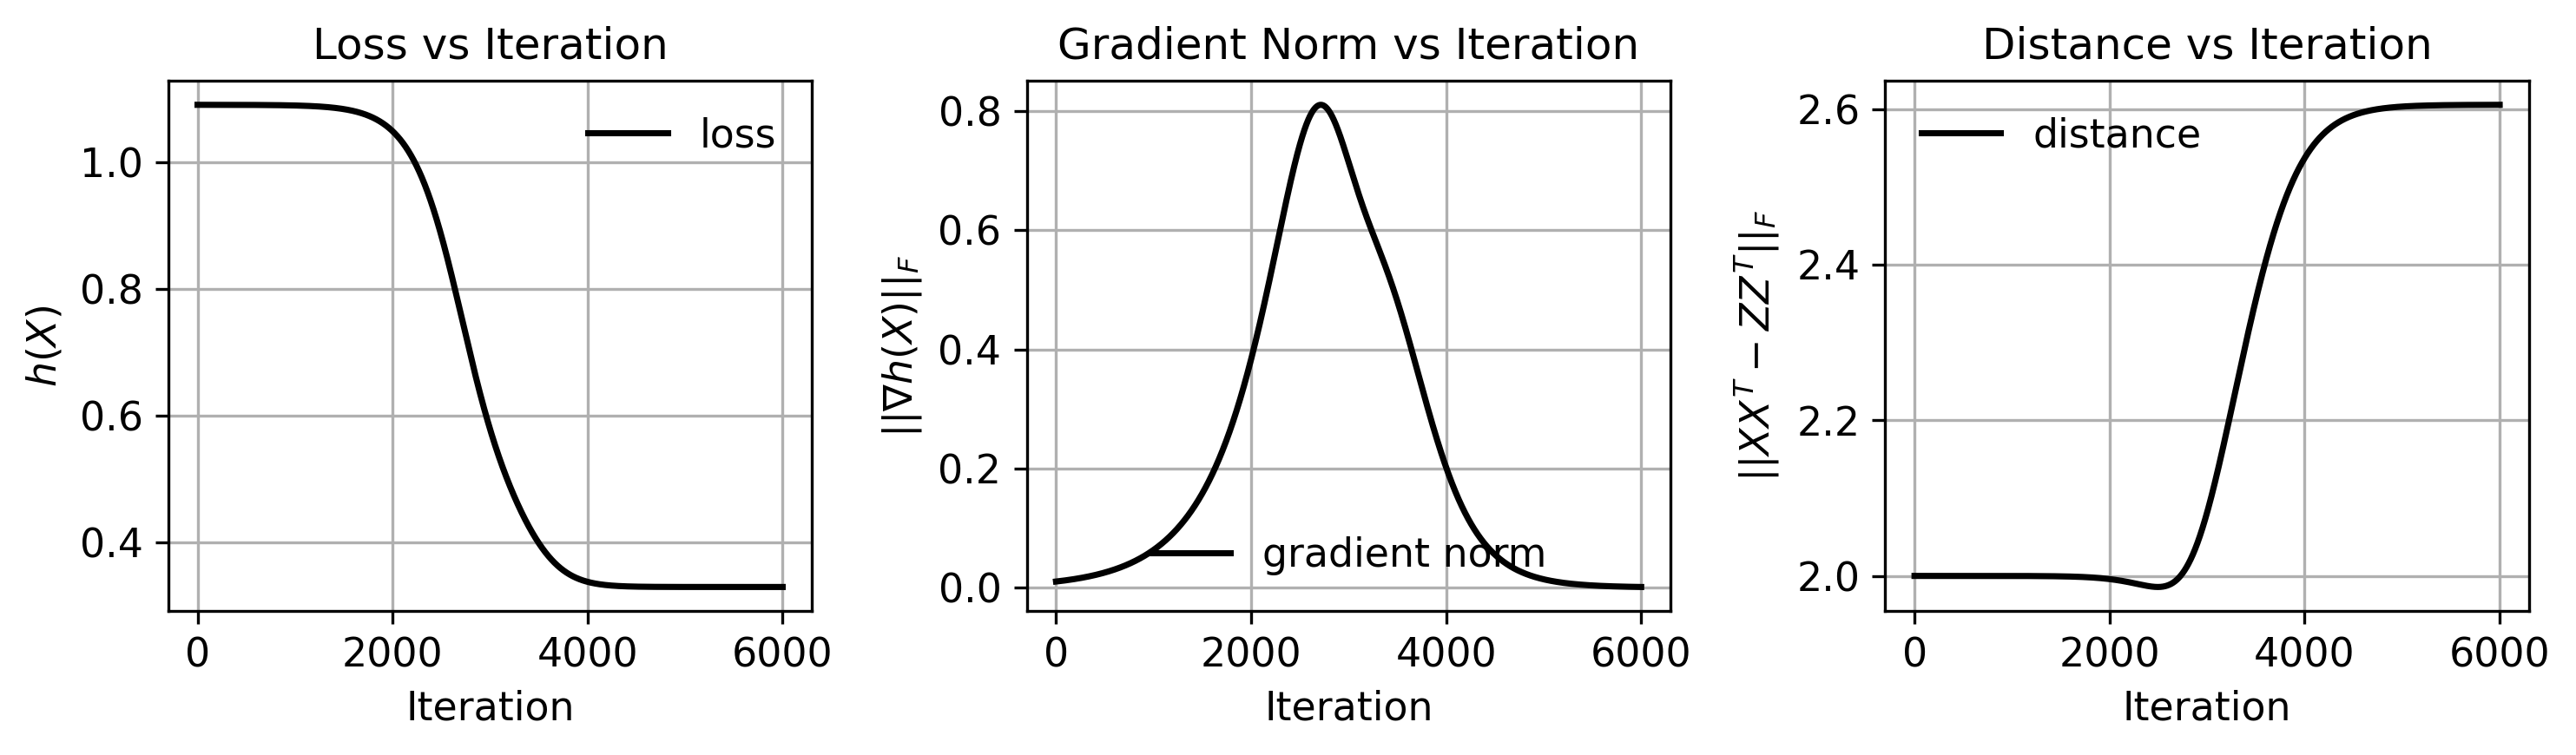

In [6]:
b = apply_A(A, M_star)
X_origin = np.zeros((n, r), dtype=float)
rng = np.random.default_rng(args.seed)
X0 = X_origin + args.init_eps * rng.normal(size=X_origin.shape)  # Small Initialization, Arxiv: 2106.15013
traj_before, losses_before, gradnorms_before, dists_before = run_gd(
    A, Z, b, X0, args.gd_lr, args.gd_steps_before_lift, args.gd_gradtol)
X_hat = traj_before[-1]
M_hat = X_hat @ X_hat.T
print("X_hat: \n", X_hat)
print(len(traj_before))
print(len(losses_before))
print(len(gradnorms_before))
print(len(dists_before))

# Set up a 1x3 grid of subplots
fig1, axes1 = plt.subplots(1, 3, figsize=(10, 3))

ax1A = axes1[0]
ax1A.plot(range(args.gd_steps_before_lift+1), losses_before, color='black', label='loss', linewidth=1.7)
ax1A.set_xlabel('Iteration', fontsize=11)
ax1A.set_ylabel(r'$h(X)$', fontsize=11)
ax1A.tick_params(axis='both', labelsize=11)
ax1A.set_title('Loss vs Iteration', fontsize=12)
ax1A.legend(frameon=False, fontsize=11)
ax1A.grid(True)

ax1B = axes1[1]
ax1B.plot(range(args.gd_steps_before_lift+1), gradnorms_before, color='black', label='gradient norm', linewidth=1.7)
ax1B.set_xlabel('Iteration', fontsize=11)
ax1B.set_ylabel(r'$||\nabla h(X)||_F$', fontsize=11)
ax1B.tick_params(axis='both', labelsize=11)
ax1B.set_title('Gradient Norm vs Iteration', fontsize=12)
ax1B.legend(frameon=False, loc="lower center", fontsize=11)
ax1B.grid(True)

ax1C = axes1[2]
ax1C.plot(range(args.gd_steps_before_lift+1), dists_before, color='black', label='distance', linewidth=1.7)
ax1C.set_xlabel('Iteration', fontsize=11)
ax1C.set_ylabel(r'$||XX^T - ZZ^T||_F$', fontsize=11)
ax1C.tick_params(axis='both', labelsize=11)
ax1C.set_title('Distance vs Iteration', fontsize=12)
ax1C.legend(frameon=False, fontsize=11)
ax1C.grid(True)

plt.tight_layout()
plt.show()

### Compute the Escape Feasibility Score (EFS)
The Escape Feasibility Score is defined as:
$$
\mathrm{EFS} :=
\underbrace{
    \frac{-\lambda_n}{\sigma_r^2(1+\delta_p)}
}_{:=\mathrm{CSR}}
+
\underbrace{
    \frac{(\mathrm{daa\_tmp})^2}{2(1+\delta_p)^2}
}_{:=\mathrm{DAA}},
$$
where
$$
\mathrm{daa\_tmp} :=
\sum_{i=1}^m \langle A_i, u_n v_r^\top + v_r u_n^\top \rangle \langle A_i, u_n u_n^\top \rangle.
$$
If $\mathrm{EFS}>1$, the current point $\hat{x}$ is escapeable via a single-step perturbation.

In [7]:
residual = apply_A(A, M_hat) - b
G = adjoint_A(A, residual)
lambda_min, u_n = min_eigpair_symmetric(G)
sigma_r, v_r, q_r = last_nonzero_singular_triplet(X_hat)
uvvu = np.outer(u_n, v_r) + np.outer(v_r, u_n)
uu = np.outer(u_n, u_n)
daa_tmp = np.sum(
    np.sum(A * uvvu, axis=(1, 2)) * np.sum(A * uu, axis=(1, 2))
)
delta_p = estimate_delta_p(A, p=args.r, num_samples=args.delta_samples, seed=args.seed,
                           matrix_type='symmetric', normalize=False)
CSR = (-lambda_min) / (sigma_r ** 2 * (1 + delta_p))
DAA = (daa_tmp ** 2) / (2 * (1 + delta_p) ** 2)
EFS = CSR + DAA

print("===== Single Step Escape =====")
print(f"n={n}, m={m}, r={r}, delta_p={delta_p:.6f}")
print(f"lambda_min={lambda_min:.6f}, sigma_r={sigma_r:.6f}, daa_tmp={daa_tmp:.6f}")
print(f"CSR={CSR:.6f}, DAA={DAA:.6f}, EFS={EFS:.6f}")

===== Single Step Escape =====
n=3, m=9, r=1, delta_p=0.865894
lambda_min=-0.330320, sigma_r=1.292141, daa_tmp=0.003493
CSR=0.106030, DAA=0.000002, EFS=0.106031


### Simulated Tensor Over-parameterization
We consider three base tensors in the lifted subspace $S$:
$$
\begin{aligned}
\mathrm{a\_vec} := \operatorname{vec}(\hat{X}),
&\quad
\mathbf{a} := \operatorname{vec}(\hat{X})^{\otimes l},
\\
\mathrm{b\_vec} := \operatorname{vec}(u_n q_r^\top),
&\quad
\mathbf{b} := \operatorname{vec}(u_n q_r^\top)^{\otimes l},
\\
\mathrm{c\_vec} := \operatorname{vec}(\mathcal{A}^*\mathcal{A}(u_n v_r^\top + v_r u_n^\top)\hat{X}),
&\quad
\mathbf{c} := \operatorname{vec}(\mathcal{A}^*\mathcal{A}(u_n v_r^\top + v_r u_n^\top)\hat{X})^{\otimes l}.
\end{aligned}
$$
We define the perturbed tensor (escape direction) as:
$$
\mathbf{w}_\text{escape} := \mathbf{a} + \rho \cdot \mathbf{b}.
$$
The lifted objective at the saddle point is denoted as:
$$
h^l(\hat{\mathbf{w}})=h^l(\mathbf{a})=:\mathrm{hl\_alpha\_a},
$$
assuming $\tilde{\alpha}^{(t)}=1$ during the truncated projected gradient descent (simulated) process.  
The geometric sum used in coefficient updates is:
$$
\sum_{\tau=0}^t \nu^\tau = \frac{1-\nu^{t+1}}{1-\nu},\quad \text{where}\ \nu:=1-\eta\lambda^l.
$$
The dynamics of the lifted rank-1 tensors are:
$$
\begin{aligned}
\tilde{\alpha}^{(t)} = 1,\quad \mathrm{a\_lift} = \tilde{\alpha}^{(t)} \cdot \mathbf{a},
&\quad \mathrm{hl\_alpha\_a} = h^l(\mathrm{a\_lift}),
\\
\tilde{\beta}^{(t)} = \rho\nu^t,\quad \mathrm{b\_lift} = \tilde{\beta}^{(t)} \cdot \mathbf{b},
&\quad \mathrm{hl\_beta\_b} = h^l(\mathrm{b\_lift}),
\\
\tilde{\gamma}^{(t)} = -\eta\rho\frac{\sigma_r^l}{2^{l-1}}(\sum_{\tau=0}^{t-1} \nu^\tau),
\quad \mathrm{c\_lift} = \tilde{\gamma}^{(t)} \cdot \mathbf{c},
&\quad \mathrm{hl\_gamma\_c} = h^l(\mathrm{c\_lift}).
\end{aligned}
$$
- If $\|\mathrm{c\_lift}\|_F \gg \max\{\|\mathrm{a\_lift}\|_F, \|\mathrm{b\_lift}\|_F\}$ and $\mathrm{hl\_gamma\_c}<h^l(\hat{\mathbf{w}})$, then escape is successful via collapsing the $\mathrm{c\_lift}$ term.
- If $\|\mathrm{b\_lift}\|_F \gg \max\{\|\mathrm{a\_lift}\|_F, \|\mathrm{c\_lift}\|_F\}$ and $\mathrm{hl\_beta\_b}<h^l(\hat{\mathbf{w}})$, then escape is successful via collapsing the $\mathrm{b\_lift}$ term.

In [8]:
l = args.l
a_vec = X_hat.reshape(-1)
b_vec = np.outer(u_n, q_r).reshape(-1)
c_vec = (adjoint_A(A, apply_A(A, uvvu)) @ X_hat).reshape(-1)
lam_pow = lambda_min ** l
nu = 1.0 - args.eta * lam_pow

def geom_sum(t):
    if abs(nu - 1.0) < 1e-12:
        return float(t + 1)
    return float((1.0 - (nu ** (t + 1))) / (1.0 - nu))

T = args.t
alpha_t = 1.0  # does not change with t
a_vec_lift = kron_power_vec(a_vec, l)
b_vec_lift = kron_power_vec(b_vec, l)
c_vec_lift = kron_power_vec(c_vec, l)
a_lift = alpha_t * a_vec_lift

hl_alpha_a_approx = tensor_objective_approx(A, [(alpha_t, a_vec)], Z, level=l)
hl_w_escape_approx = tensor_objective_approx(A, [(alpha_t, a_vec), (args.rho, b_vec)], Z, level=l)
print("Approximated Version of h(hat_w): ", hl_alpha_a_approx)
print("Approximated Version of h(w_escape): ", hl_w_escape_approx)

Approximated Version of h(hat_w):  1.488696074686553
Approximated Version of h(w_escape):  1.4883835242474537


In [9]:
#hl_beta_b_list = []
#hl_gamma_c_list = []
hl_w_list = []
a_lift_list = []
b_lift_list = []
c_lift_list = []

for tt in tqdm(range(T)):
    beta_t = args.rho * (nu ** (tt + 1))
    gamma_t = -args.eta * args.rho * ((sigma_r ** l) / (2 ** (l - 1))) * geom_sum(tt)
    b_lift = beta_t * b_vec_lift
    c_lift = gamma_t * c_vec_lift
    
    hl_beta_b_approx = tensor_objective_approx(A, [(beta_t, b_vec)], Z, level=l)
    hl_gamma_c_approx = tensor_objective_approx(A, [(gamma_t, c_vec)], Z, level=l)
    hl_w_t_approx = tensor_objective_approx(A, [(alpha_t, a_vec), 
                                                (beta_t, b_vec), 
                                                (gamma_t, c_vec)], Z, level=l)
    #hl_beta_b_list.append(hl_beta_b_approx)
    #hl_gamma_c_list.append(hl_gamma_c_approx)
    hl_w_list.append(hl_w_t_approx)
    
    a_lift_norm = np.linalg.norm(a_lift)
    b_lift_norm = np.linalg.norm(b_lift)
    c_lift_norm = np.linalg.norm(c_lift)
    a_lift_list.append(a_lift_norm)
    b_lift_list.append(b_lift_norm)
    c_lift_list.append(c_lift_norm)

print("===== Lifted objective values =====")
print(f"h^l(alpha_a_approx) = {hl_alpha_a_approx:.10f}")
print(f"h^l(beta_b_approx) = {hl_beta_b_approx:.10f}")
print(f"h^l(gamma_c_approx) = {hl_gamma_c_approx:.10f}")
print(f"h^l(w_hat_approx)    = {hl_alpha_a_approx:.10f}")
print(f"h^l(w_escape_approx) = {hl_w_escape_approx:.10f}")
print(f"h(w^(t+1))  = {hl_w_t_approx:.10f}")
print(f"||alpha*a||={a_lift_list[-1]:.6f}, "
      f"||beta*b||={b_lift_list[-1]:.6f}, "
      f"||gamma*c||={c_lift_list[-1]:.6f}")

# Collapse selection (relaxed dominance)
collapse_ok = False
collapse_mode = None
X_check = None
if hl_w_t_approx < hl_alpha_a_approx:
    if (c_lift_norm > b_lift_norm) and (c_lift_norm > a_lift_norm):
        collapse_ok = True
        collapse_mode = "gamma"
        #hl_vals = hl_gamma_c_list
    elif (b_lift_norm > c_lift_norm) and (b_lift_norm > a_lift_norm):
        collapse_ok = True
        collapse_mode = "beta"
        #hl_vals = hl_beta_b_list
    else:
        print("Simulating Tensor Over-parameterization Failed!")
else:
    print("collapse_ok is", collapse_ok)

100%|███████████████████████████████████| 59000/59000 [00:49<00:00, 1181.56it/s]

===== Lifted objective values =====
h^l(alpha_a_approx) = 1.4886960747
h^l(beta_b_approx) = 1.9998230945
h^l(gamma_c_approx) = 0.0499002118
h^l(w_hat_approx)    = 1.4886960747
h^l(w_escape_approx) = 1.4883835242
h(w^(t+1))  = 1.3332726866
||alpha*a||=16.765208, ||beta*b||=0.300906, ||gamma*c||=48.656499


### Visualization of Simulated Tensor Over-parameterization

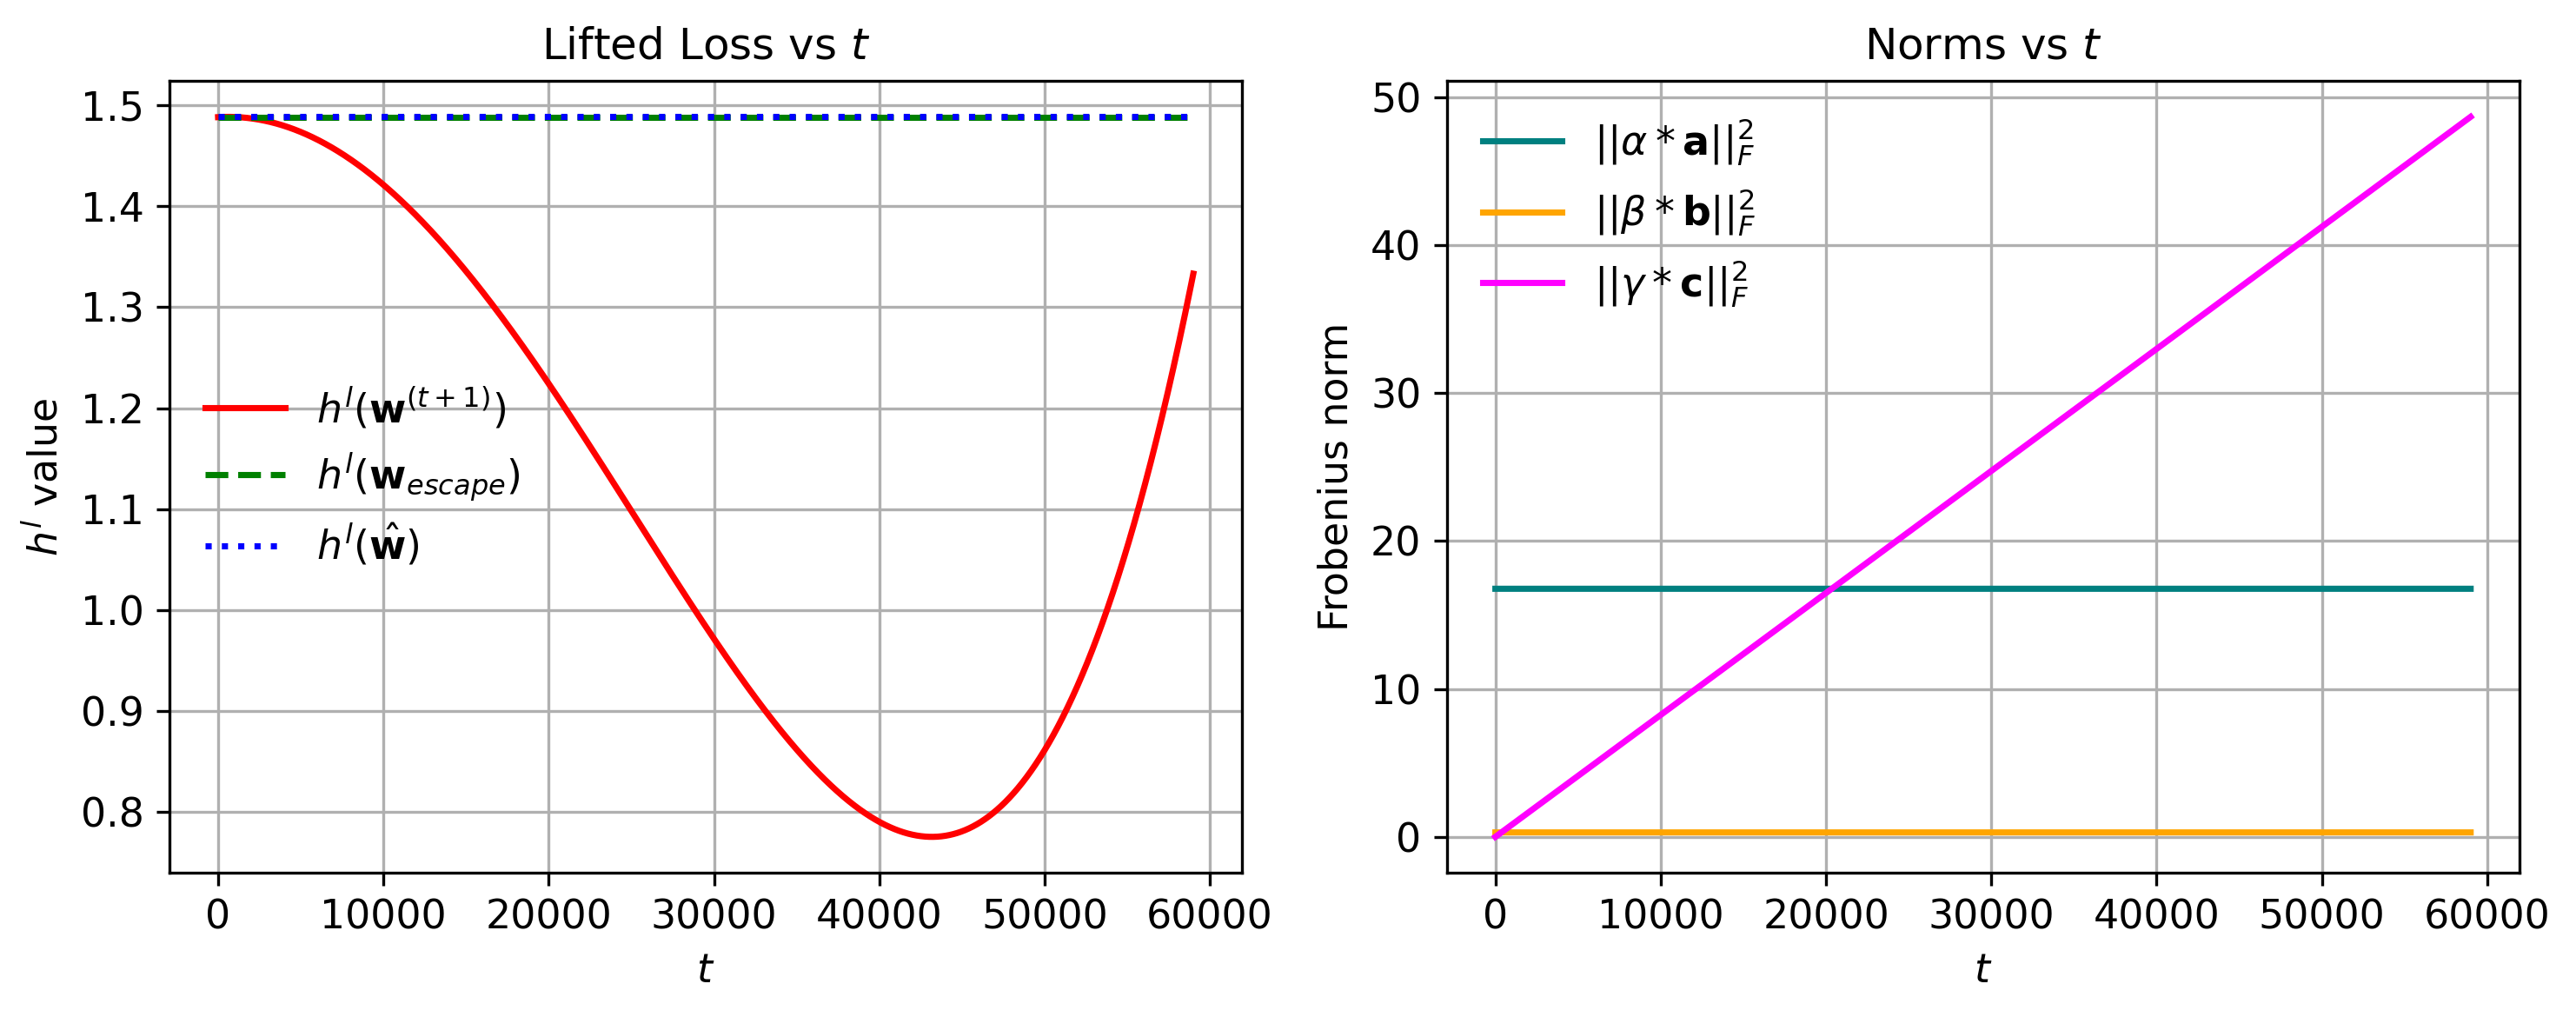

In [10]:
# Set up a 1x2 grid of subplots
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))

ax2D = axes2[0]
ax2D.plot(range(T), hl_w_list, color='red', label=r'$h^l(\mathbf{w}^{(t+1)})$', linewidth=1.7)
ax2D.hlines(hl_w_escape_approx, xmin=0, xmax=args.t, 
            linestyle='--', color='green', label=r'$h^l(\mathbf{w}_{escape})$', linewidth=1.7)
ax2D.hlines(hl_alpha_a_approx, xmin=0, xmax=args.t, 
            linestyle=':', color='blue', label=r'$h^l(\hat{\mathbf{w}})$', linewidth=1.7)
ax2D.set_xlabel(r'$t$', fontsize=11)
ax2D.set_ylabel(r'$h^l$ value', fontsize=11)
ax2D.tick_params(axis='both', labelsize=11)
ax2D.set_title('Lifted Loss vs $t$', fontsize=12)
ax2D.legend(frameon=False, loc='center left', fontsize=11)
ax2D.grid(True)

ax2E = axes2[1]
ax2E.plot(range(T), a_lift_list, color='teal', label=r'$||\alpha * \mathbf{a}||_F^2$', linewidth=1.7)
ax2E.plot(range(T), b_lift_list, color='orange', label=r'$||\beta * \mathbf{b}||_F^2$', linewidth=1.7)
ax2E.plot(range(T), c_lift_list, color='magenta', label=r'$||\gamma * \mathbf{c}||_F^2$', linewidth=1.7)
ax2E.set_xlabel(r'$t$', fontsize=11)
ax2E.set_ylabel('Frobenius norm', fontsize=11)
ax2E.tick_params(axis='both', labelsize=11)
ax2E.set_title('Norms vs $t$', fontsize=12)
ax2E.legend(frameon=False, fontsize=11)
ax2E.grid(True)

plt.tight_layout()
plt.savefig('exp2_fig1.pdf', dpi=300, format='pdf')
plt.show()

### Collapse from Tensor Space via Closed-Form Solution
- If collapsing $\mathrm{c\_lift}$ term:
$$
\check{X} = -(-\tilde{\gamma}^{(t)})^{\frac{1}{l}} \cdot \mathcal{A}^*\mathcal{A}(u_n v_r^\top + v_r u_n^\top)\hat{X}
\in\mathbb{R}^{n\times r};
$$
- If collapsing $\mathrm{b\_lift}$ term:
$$
\check{X} = (\tilde{\beta}^{(t)})^{\frac{1}{l}} \cdot (u_n q_r^\top) \in\mathbb{R}^{n\times r}.
$$

As a result, $\check{X}$ lies in matrix space and represents a point that successfully escapes the attraction basin of $\hat{X}$.  
**Note:** Since $\check{X}$ admits a closed-form expression, **there is no need to perform actual tensor lifting** — the procedure is purely simulated.

In [11]:
print("collapse_mode is", collapse_mode)
if collapse_ok:
    if collapse_mode == "gamma":
        scale = np.sign(gamma_t) * (abs(gamma_t) ** (1.0 / l)) if gamma_t != 0 else 0.0
        X_check = (scale * c_vec).reshape(n, r)
    elif collapse_mode == "beta":
        scale = np.sign(beta_t) * (abs(beta_t) ** (1.0 / l)) if beta_t != 0 else 0.0
        X_check = (scale * b_vec).reshape(n, r)

collapse_mode is gamma


### Run GD in Matrix Space (Post-Escape Phase)

In [12]:
# If collapse performed, run GD from X_check
traj_after = []
losses_after = []
gradnorms_after = []
dists_after = []
#losses_full = list(losses_before)
#gradnorms_full = list(gradnorms_before)
#dists_full = list(dists_before)

if X_check is not None:
    traj_after, losses_after, gradnorms_after, dists_after = run_gd(
        A, Z, b, X_check, args.gd_lr, args.gd_steps_after_collapse, args.gd_gradtol)
    #losses_full.extend(losses_after)
    #gradnorms_full.extend(gradnorms_after)
    #dists_full.extend(dists_after)

print(len(traj_after))
print(len(losses_after))
print(len(gradnorms_after))
print(len(dists_after))

1501
1501
1501
1501


### Full Procedure Visualization

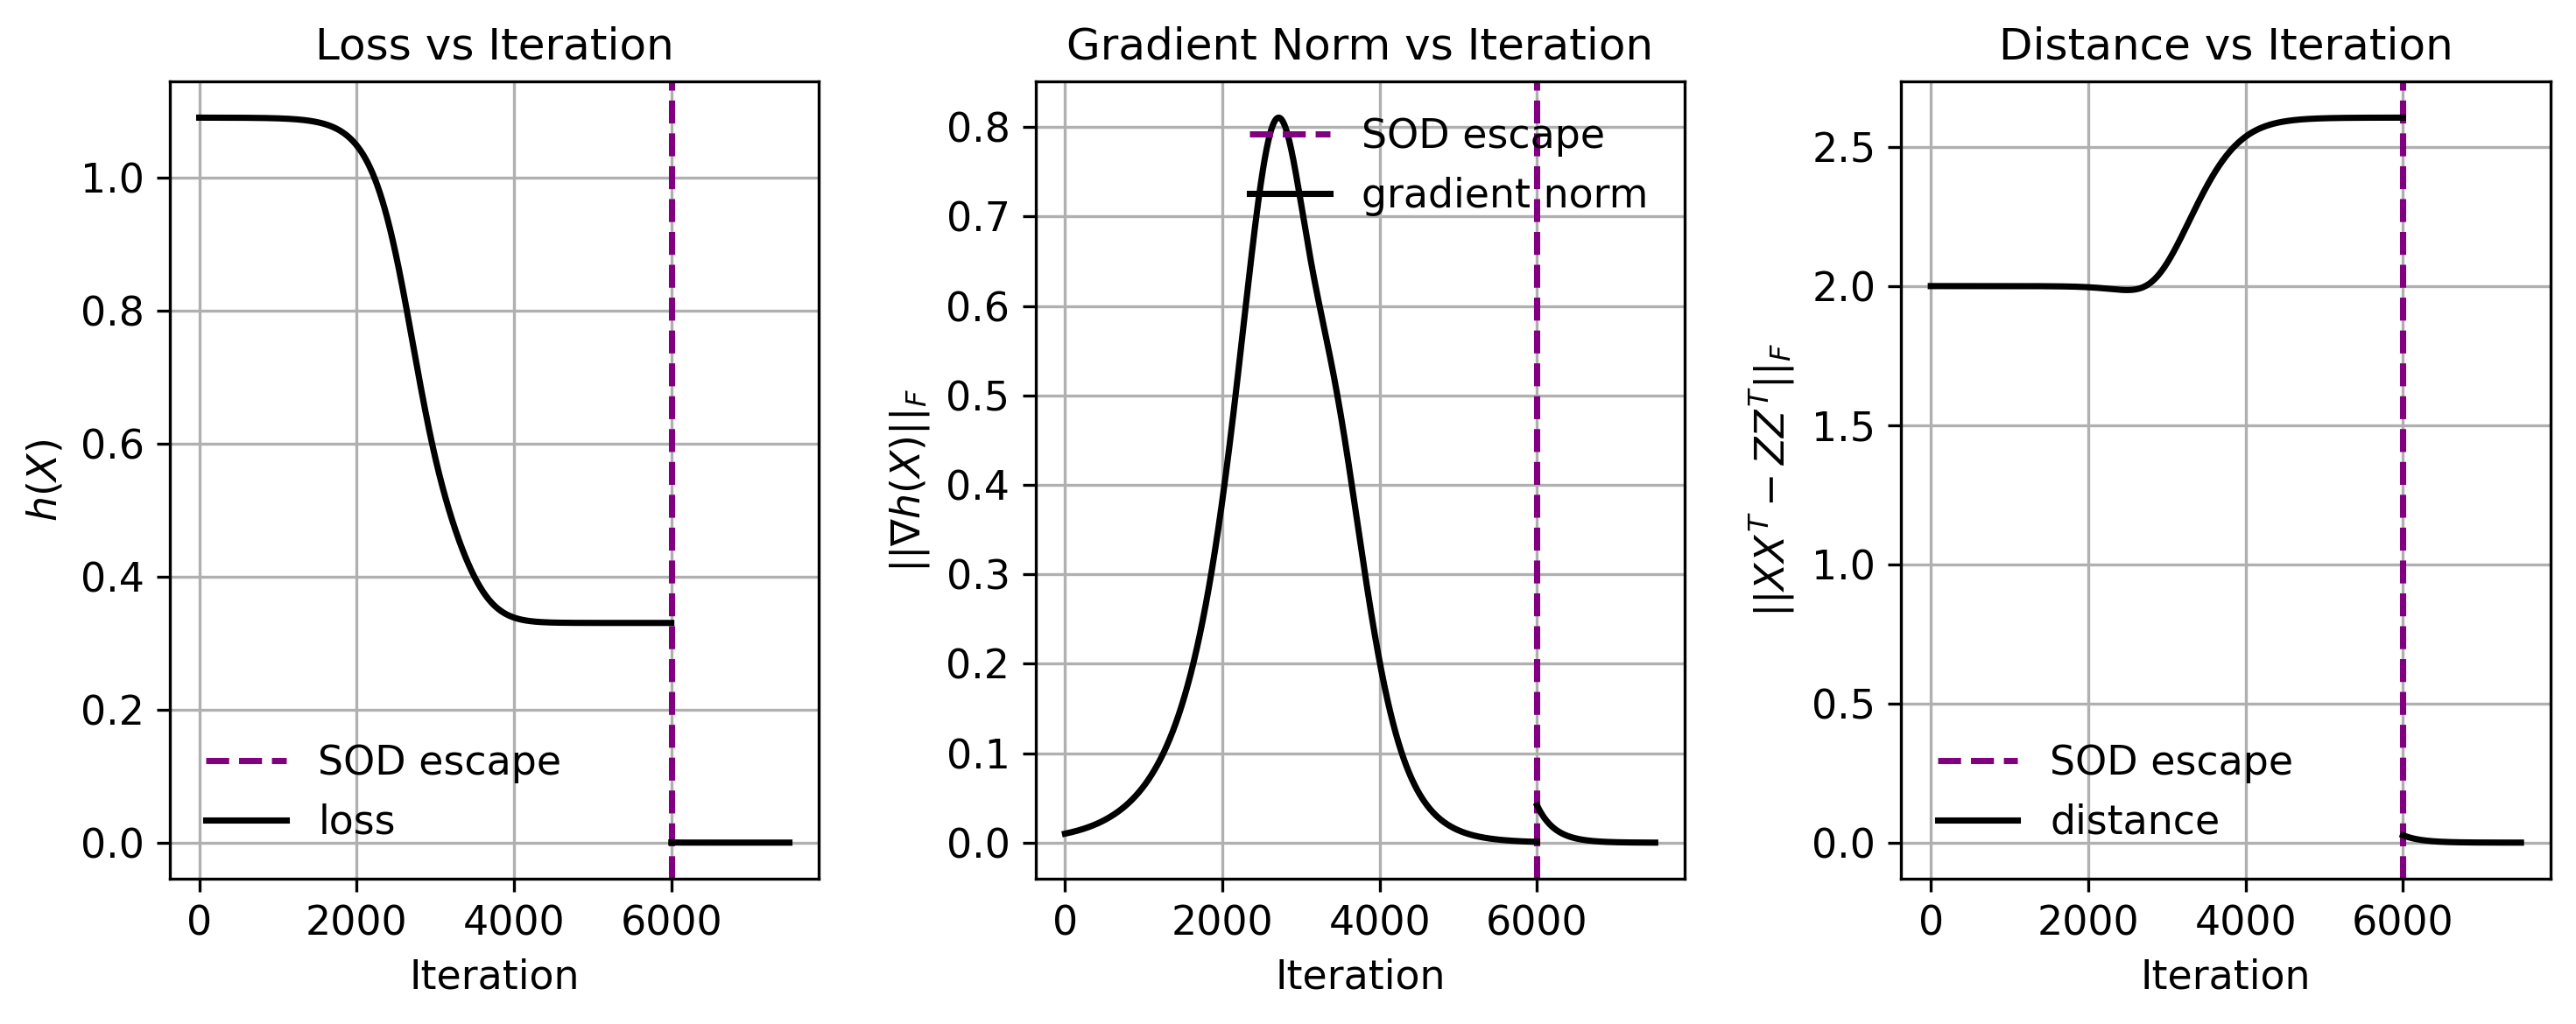

In [15]:
# Set up a 1x3 grid of subplots
fig3, axes3 = plt.subplots(1, 3, figsize=(10, 4))

ax3A = axes3[0]
ax3A.axvline(len(losses_before) - 1, linestyle='--', color='purple', label='SOD escape', linewidth=1.7)
ax3A.plot(range(args.gd_steps_before_lift + 1), 
          losses_before, color='black', label='loss', linewidth=1.7)
if len(losses_after) > 0:
    ax3A.plot(range(args.gd_steps_before_lift + 1, args.gd_steps_before_lift + args.gd_steps_after_collapse + 2), 
              losses_after, color='black', linewidth=1.7)
ax3A.set_xlabel('Iteration', fontsize=11)
ax3A.set_ylabel(r'$h(X)$', fontsize=11)
ax3A.tick_params(axis='both', labelsize=11)
ax3A.set_title('Loss vs Iteration', fontsize=12)
ax3A.legend(frameon=False, fontsize=11)
ax3A.grid(True)

ax3B = axes3[1]
ax3B.axvline(len(gradnorms_before) - 1, linestyle='--', color='purple', label='SOD escape', linewidth=1.7)
ax3B.plot(range(args.gd_steps_before_lift + 1), 
          gradnorms_before, color='black', label='gradient norm', linewidth=1.7)
if len(gradnorms_after) > 0:
    ax3B.plot(range(args.gd_steps_before_lift + 1, args.gd_steps_before_lift + args.gd_steps_after_collapse + 2), 
              gradnorms_after, color='black', linewidth=1.7)
ax3B.set_xlabel('Iteration', fontsize=11)
ax3B.set_ylabel(r'$||\nabla h(X)||_F$', fontsize=11)
ax3B.tick_params(axis='both', labelsize=11)
ax3B.set_title('Gradient Norm vs Iteration', fontsize=12)
ax3B.legend(frameon=False, loc='upper right', fontsize=11)
ax3B.grid(True)

ax3C = axes3[2]
ax3C.axvline(len(dists_before) - 1, linestyle='--', color='purple', label='SOD escape', linewidth=1.7)
ax3C.plot(range(args.gd_steps_before_lift + 1), 
          dists_before, color='black', label='distance', linewidth=1.7)
if len(dists_after) > 0:
    ax3C.plot(range(args.gd_steps_before_lift + 1, args.gd_steps_before_lift + args.gd_steps_after_collapse + 2), 
              dists_after, color='black', linewidth=1.7)
ax3C.set_xlabel('Iteration', fontsize=11)
ax3C.set_ylabel(r'$||XX^T - ZZ^T||_F$', fontsize=11)
ax3C.tick_params(axis='both', labelsize=11)
ax3C.set_title('Distance vs Iteration', fontsize=12)
ax3C.legend(frameon=False, loc='lower left', fontsize=11)
ax3C.grid(True)

plt.tight_layout()
plt.savefig('exp2_fig2.pdf', dpi=300, format='pdf')
plt.show()

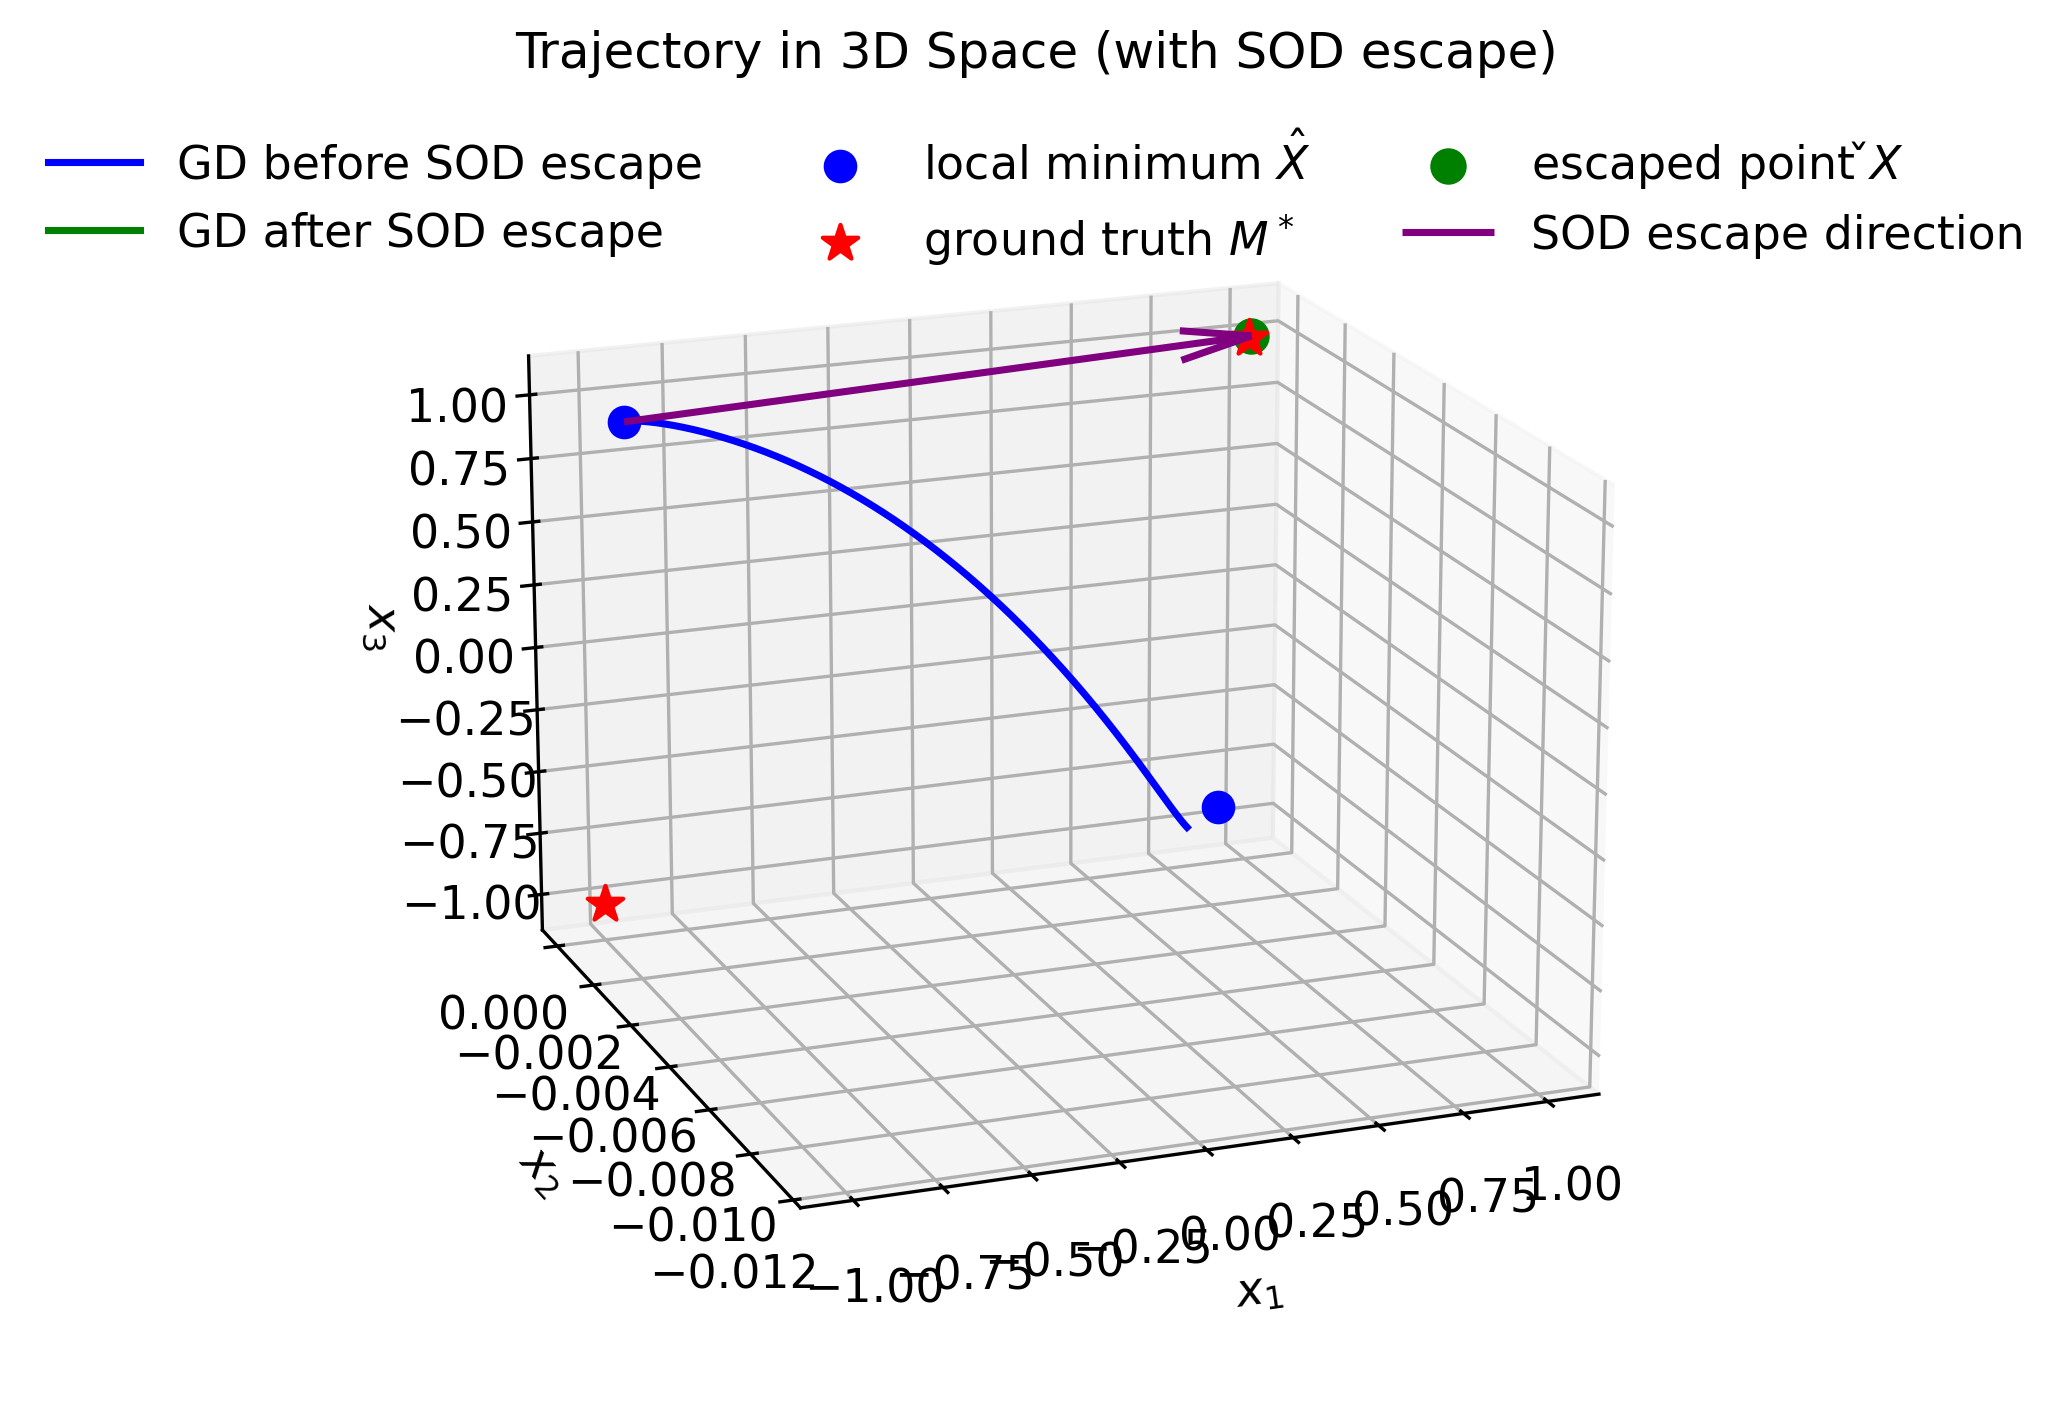

In [14]:
P_before = np.array([X.reshape(-1) for X in traj_before])
P_after = np.array([X.reshape(-1) for X in traj_after]) if len(traj_after) > 0 else None
pt_local = X_hat.reshape(-1)
pt_gt = Z.reshape(-1)
pt_check = X_check.reshape(-1) if X_check is not None else None

# Plot 3d Trajectory
fig4 = plt.figure()
ax3d = fig4.add_subplot(1, 1, 1, projection='3d')
ax3d.plot(P_before[:, 0], P_before[:, 1], P_before[:, 2], 
          color='blue', label='GD before SOD escape', linewidth=1.7)
if P_after is not None and P_after.shape[0] > 0:
    ax3d.plot(P_after[:, 0], P_after[:, 1], P_after[:, 2], 
              color='green', label='GD after SOD escape', linewidth=1.7)
# markers
ax3d.scatter(pt_local[0], pt_local[1], pt_local[2], 
             color='blue', marker='o', s=50, label=r'local minimum $\hat{X}$')
ax3d.scatter(pt_gt[0], pt_gt[1], pt_gt[2], 
             color='red', marker='*', s=80, label=r'ground truth $M^*$')
ax3d.scatter(-pt_local[0], -pt_local[1], -pt_local[2], color='blue', marker='o', s=50)
ax3d.scatter(-pt_gt[0], -pt_gt[1], -pt_gt[2], color='red', marker='*', s=80)
if pt_check is not None:
    ax3d.scatter(pt_check[0], pt_check[1], pt_check[2], 
                 color='green', marker='o', s=60, label=r'escaped point $\check{X}$')
    # jump arrow
    diff = pt_check - pt_local
    if float(np.linalg.norm(diff)) > 1e-12:
        ax3d.quiver(pt_local[0], pt_local[1], pt_local[2], diff[0], diff[1], diff[2], 
                    arrow_length_ratio=0.12, color='purple', linewidth=1.7, label='SOD escape direction')
ax3d.set_xlabel(r'$x_1$', fontsize=11)
ax3d.set_ylabel(r'$x_2$', fontsize=11)
ax3d.set_zlabel(r'$x_3$', fontsize=11)
ax3d.tick_params(axis='x', labelsize=11)
ax3d.tick_params(axis='y', labelsize=11)
ax3d.tick_params(axis='z', labelsize=11)
ax3d.set_title('Trajectory in 3D Space (with SOD escape)', fontsize=12)
ax3d.legend(frameon=False, ncol=3, loc='upper center', fontsize=11)
ax3d.view_init(elev=18, azim=-111)

plt.tight_layout()
plt.savefig('exp2_fig3.pdf', dpi=300, format='pdf')
plt.show()